# Notebook 02 — Classical Computer Vision Baseline

## Objective

The goal of this notebook is to build the first simple baseline for binary satellite image change detection.

The method is based on classical computer vision:

1. Convert before and after images to grayscale.
2. Compute absolute pixel difference.
3. Apply thresholding.
4. Use morphological operations to clean the predicted mask.
5. Evaluate the prediction against the ground truth mask.

This baseline does not use machine learning. Its purpose is to provide a simple reference point for later models.

# 1. Imports

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

In [3]:
DATA_PATH = "../data/raw"

TRAIN_PATH = os.path.join(DATA_PATH, "train")
VAL_PATH = os.path.join(DATA_PATH, "val")
TEST_PATH = os.path.join(DATA_PATH, "test")

In [4]:
def predict_change_mask(before, after):

    # grayscale
    before_gray = cv2.cvtColor(
        before,
        cv2.COLOR_RGB2GRAY
    )

    after_gray = cv2.cvtColor(
        after,
        cv2.COLOR_RGB2GRAY
    )

    # blur
    before_blur = cv2.GaussianBlur(
        before_gray,
        (5,5),
        0
    )

    after_blur = cv2.GaussianBlur(
        after_gray,
        (5,5),
        0
    )

    # difference
    diff = cv2.absdiff(
        before_blur,
        after_blur
    )

    # threshold
    adaptive_mask = cv2.adaptiveThreshold(
        diff,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        5
    )

    adaptive_mask = adaptive_mask // 255

    # morphology
    kernel = np.ones((3,3), np.uint8)

    clean_mask = cv2.morphologyEx(
        adaptive_mask.astype(np.uint8),
        cv2.MORPH_OPEN,
        kernel
    )

    clean_mask = cv2.morphologyEx(
        clean_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    return clean_mask

In [5]:
def evaluate_prediction(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    iou = jaccard_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou
    }

In [6]:
def evaluate_split(split_path):

    a_path = os.path.join(split_path, "A")
    b_path = os.path.join(split_path, "B")
    label_path = os.path.join(split_path, "label")

    image_names = sorted(
        os.listdir(a_path)
    )

    results = []

    for name in tqdm(image_names):

        before = cv2.imread(
            os.path.join(a_path, name)
        )

        after = cv2.imread(
            os.path.join(b_path, name)
        )

        label = cv2.imread(
            os.path.join(label_path, name),
            cv2.IMREAD_GRAYSCALE
        )

        before = cv2.cvtColor(
            before,
            cv2.COLOR_BGR2RGB
        )

        after = cv2.cvtColor(
            after,
            cv2.COLOR_BGR2RGB
        )

        pred_mask = predict_change_mask(
            before,
            after
        )

        label_binary = (
            label > 0
        ).astype(np.uint8)

        metrics = evaluate_prediction(
            label_binary,
            pred_mask
        )

        metrics["image"] = name

        results.append(metrics)

    return pd.DataFrame(results)

In [7]:
train_results = evaluate_split(
    TRAIN_PATH
)

val_results = evaluate_split(
    VAL_PATH
)

test_results = evaluate_split(
    TEST_PATH
)

100%|██████████| 128/128 [00:50<00:00,  2.53it/s]


In [15]:
summary = pd.DataFrame({

    "split": ["train", "val", "test"],

    "precision": [
        train_results.precision.mean(),
        val_results.precision.mean(),
        test_results.precision.mean()
    ],

    "recall": [
        train_results.recall.mean(),
        val_results.recall.mean(),
        test_results.recall.mean()
    ],

    "f1": [
        train_results.f1.mean(),
        val_results.f1.mean(),
        test_results.f1.mean()
    ],

    "iou": [
        train_results.iou.mean(),
        val_results.iou.mean(),
        test_results.iou.mean()
    ]
})

summary = summary.round(4)
print(summary)

   split  precision  recall      f1     iou
0  train     0.0398  0.4753  0.0682  0.0367
1    val     0.0377  0.4839  0.0651  0.0350
2   test     0.0445  0.4813  0.0757  0.0409


Classical image differencing methods
show poor robustness to:
- illumination changes
- small geometric shifts
- texture variation

This motivates the use of
machine learning methods.

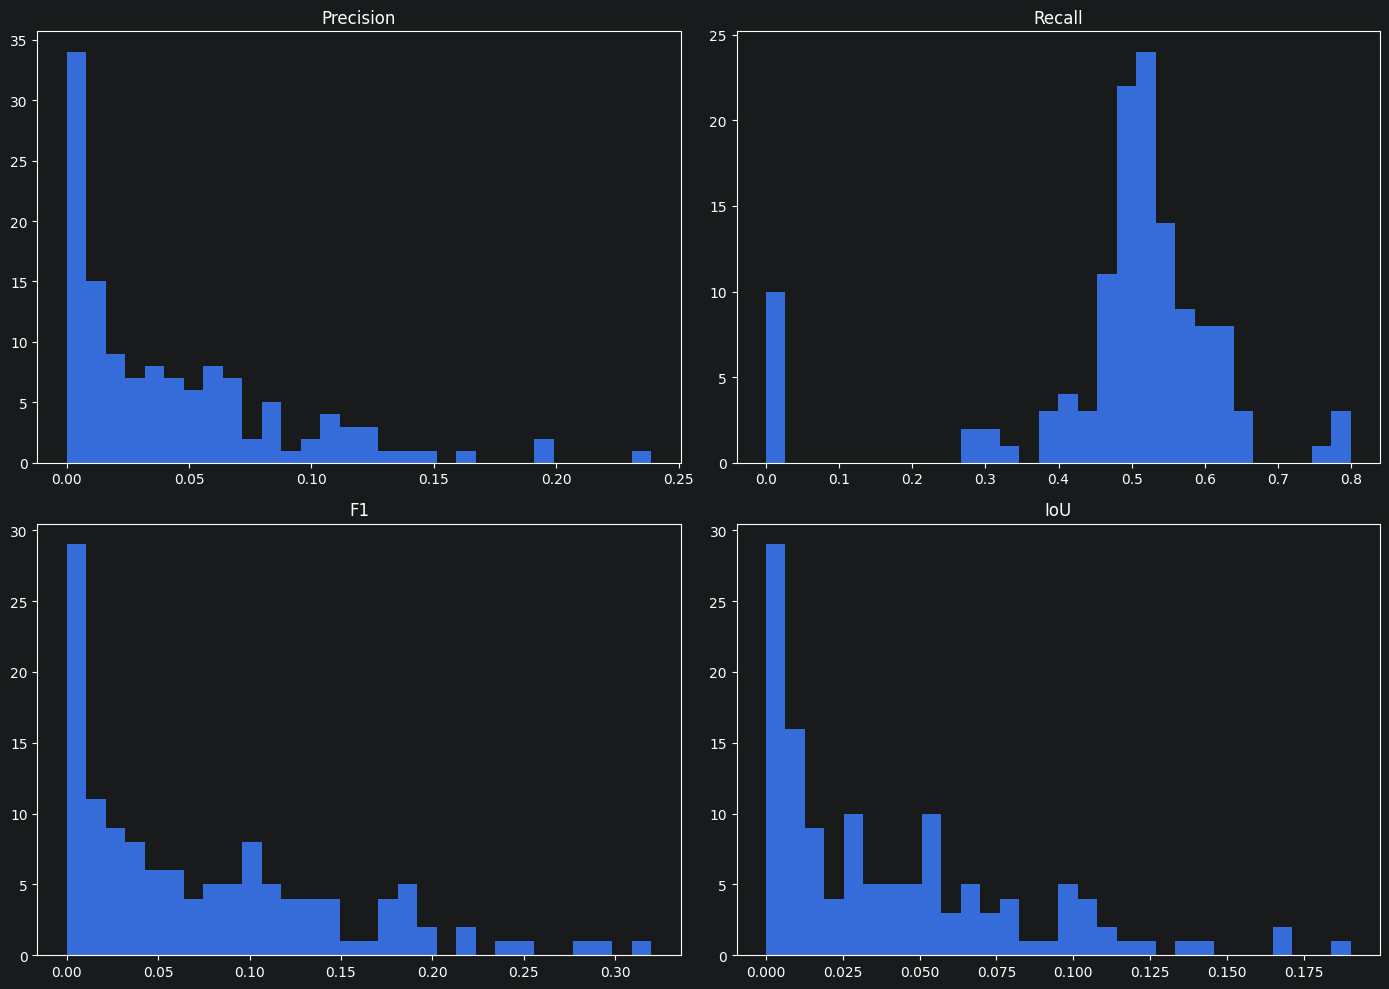

In [9]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

ax[0,0].hist(
    test_results["precision"],
    bins=30
)
ax[0,0].set_title("Precision")

ax[0,1].hist(
    test_results["recall"],
    bins=30
)
ax[0,1].set_title("Recall")

ax[1,0].hist(
    test_results["f1"],
    bins=30
)
ax[1,0].set_title("F1")

ax[1,1].hist(
    test_results["iou"],
    bins=30
)
ax[1,1].set_title("IoU")

plt.tight_layout()
plt.show()

In [10]:
best_cases = test_results.sort_values(
    "iou",
    ascending=False
)

best_cases.head()

,precision,recall,f1,iou,image
68,0.238918,0.483146,0.319729,0.190284,test_45.png
107,0.195670,0.553075,0.289071,0.168955,test_80.png
41,0.198446,0.520756,0.287380,0.167801,test_20.png
18,0.160678,0.517523,0.245221,0.139745,test_115.png
103,0.148942,0.586696,0.237572,0.134798,test_77.png


In [11]:
worst_cases = test_results.sort_values(
    "iou",
    ascending=True
)

worst_cases.head()

,precision,recall,f1,iou,image
10,0.0,0.0,0.0,0.0,test_108.png
29,0.0,0.0,0.0,0.0,test_125.png
26,0.0,0.0,0.0,0.0,test_122.png
20,0.0,0.0,0.0,0.0,test_117.png
91,0.0,0.0,0.0,0.0,test_66.png


In [12]:
def visualize_case(image_name):

    before = cv2.imread(
        os.path.join(TEST_PATH, "A", image_name)
    )

    after = cv2.imread(
        os.path.join(TEST_PATH, "B", image_name)
    )

    label = cv2.imread(
        os.path.join(
            TEST_PATH,
            "label",
            image_name
        ),
        cv2.IMREAD_GRAYSCALE
    )

    before = cv2.cvtColor(
        before,
        cv2.COLOR_BGR2RGB
    )

    after = cv2.cvtColor(
        after,
        cv2.COLOR_BGR2RGB
    )

    pred = predict_change_mask(
        before,
        after
    )

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(20,6)
    )

    ax[0].imshow(before)
    ax[0].set_title("Before")

    ax[1].imshow(after)
    ax[1].set_title("After")

    ax[2].imshow(pred, cmap="gray")
    ax[2].set_title("Prediction")

    ax[3].imshow(label, cmap="gray")
    ax[3].set_title("Ground Truth")

    for a in ax:
        a.axis("off")

    plt.show()

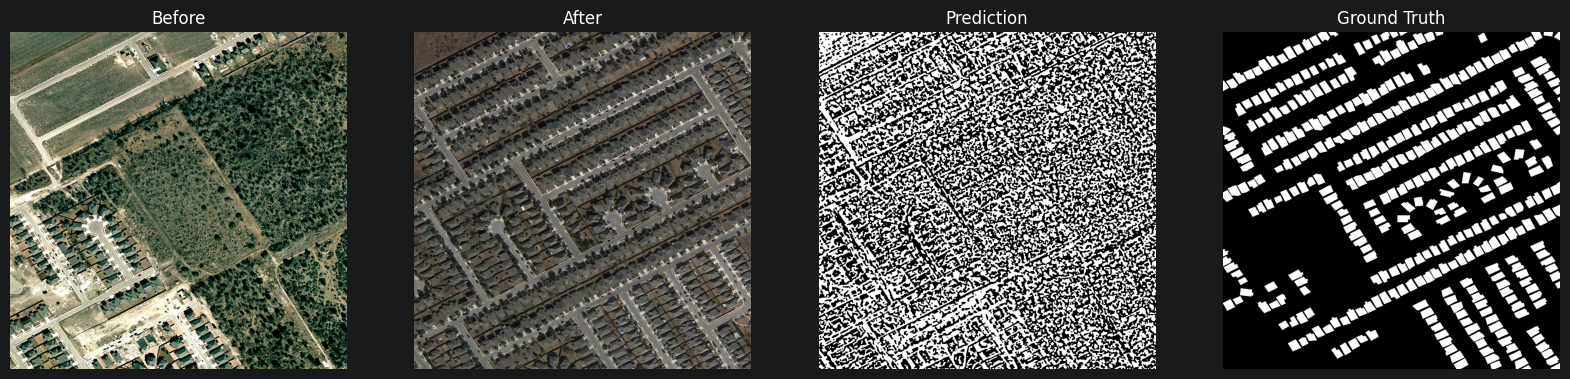

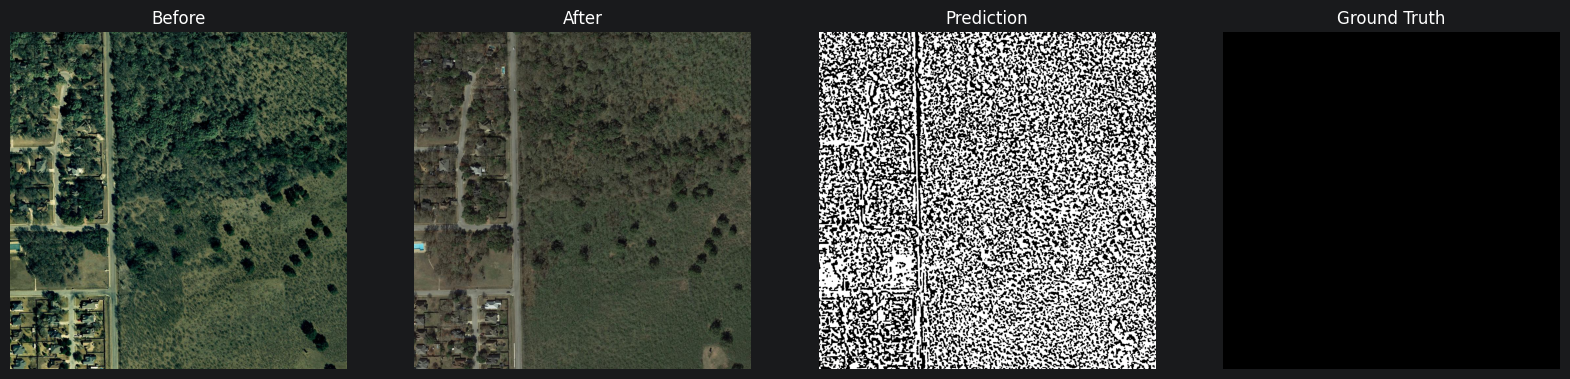

In [13]:
visualize_case(
    best_cases.iloc[0]["image"]
)

visualize_case(
    worst_cases.iloc[0]["image"]
)

## Conclusions

The classical pixel-difference baseline produced weak results on the LEVIR-CD dataset.

The method was able to detect some changed regions, but it generated many false positives. This happened because raw pixel differences react strongly to:

- illumination changes,
- shadows,
- vegetation differences,
- road textures,
- small spatial shifts between images.

The results showed that simple image differencing is not robust enough for building-level change detection.

This experiment established an important baseline and demonstrated the need for more advanced methods that can distinguish real semantic changes from general visual differences.